# 06 — Noise & Error Mitigation (Qiskit)
### QML Curriculum · Companion Notebook to Module 11 — *Advanced QML Architectures (Part 2)*

**Part of:** [Schrödinger's Cats — Quantum Machine Learning Platform](https://tanjinadnanabir.github.io/WISER-Education-Challenge/)

Every notebook so far ran on a **perfect, noiseless simulator**. Module 5's "Real Quantum Hardware" chapter called today's devices **NISQ** — Noisy, Intermediate-Scale Quantum — for a reason. This notebook makes that noise real, and walks through the two most common ways practitioners fight back against it.

**By the end of this notebook you will be able to:**
- Build a realistic **noise model** in Qiskit Aer (gate errors + readout errors)
- See, quantitatively, how noise degrades a simple quantum result
- Implement **readout error mitigation** via a calibration matrix
- Implement **Zero-Noise Extrapolation (ZNE)** via gate folding
- Know what these techniques can and can't fix

**Prerequisites:** Notebook 01 (Qiskit basics), Module 11 (conceptual).


In [1]:
# Setup
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError

np.set_printoptions(precision=3, suppress=True)
print("Ready.")

Ready.


## 1. Where Does Noise Come From?

Two broad categories matter for this notebook:

- **Gate errors:** every real gate is an imperfect physical operation — a microwave pulse or laser pulse that's never *exactly* right. We model this with **depolarizing error**: with some probability, the gate's output is replaced by a completely random state instead of the intended one.
- **Readout errors:** the final measurement itself is unreliable — a real |0⟩ sometimes reads out as `1`, and vice versa, due to imperfect detectors.

Let's build a noise model with both, at strengths loosely representative of a real NISQ device.

In [2]:
noise_model = NoiseModel()

# gate errors: 1% depolarizing on single-qubit gates, 3% on two-qubit gates
# (two-qubit gates are consistently the noisiest operation on real hardware)
error_1q = depolarizing_error(0.01, 1)
error_2q = depolarizing_error(0.03, 2)
noise_model.add_all_qubit_quantum_error(error_1q, ['h', 'x', 'ry', 'rz'])
noise_model.add_all_qubit_quantum_error(error_2q, ['cx'])

# readout error: ~3-4% chance of misreading a qubit's final state
readout_error = ReadoutError([[0.97, 0.03], [0.04, 0.96]])
noise_model.add_all_qubit_readout_error(readout_error)

sim_ideal = AerSimulator()
sim_noisy = AerSimulator(noise_model=noise_model, seed_simulator=42)
print("Ideal and noisy simulators ready.")
print(noise_model)

Ideal and noisy simulators ready.
NoiseModel:
  Basis gates: ['cx', 'h', 'id', 'ry', 'rz', 'sx', 'x']
  Instructions with noise: ['rz', 'ry', 'measure', 'x', 'h', 'cx']
  All-qubits errors: ['h', 'x', 'ry', 'rz', 'cx', 'measure']


## 2. Watching Noise Degrade a Bell Pair

Recall the Bell pair from Notebook 01: `H` then `CNOT` should give **only** `00` and `11`, never `01` or `10`. Let's run it on both simulators and compare.

Ideal simulator counts: {'11': 1942, '00': 2058}
Noisy simulator counts: {'01': 171, '00': 1847, '10': 152, '11': 1830}


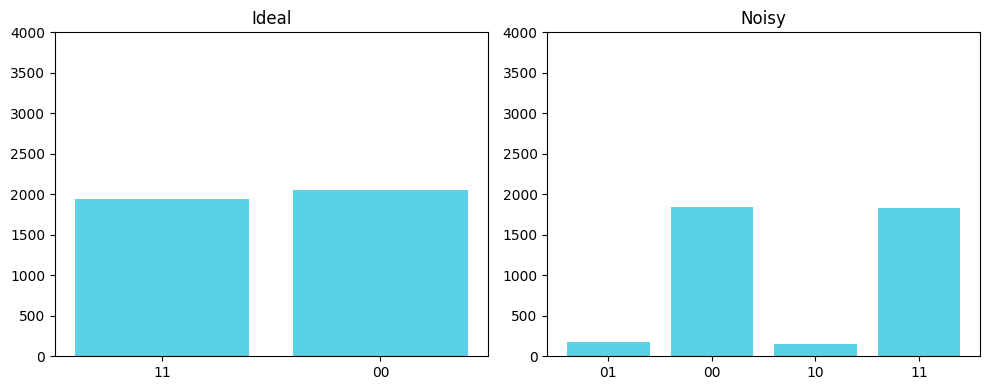


'Correct outcome' rate -- ideal: 100.0%   noisy: 91.9%


In [3]:
def bell_circuit():
    qc = QuantumCircuit(2, 2)
    qc.h(0)
    qc.cx(0, 1)
    qc.measure([0, 1], [0, 1])
    return qc

qc = bell_circuit()
shots = 4000
ideal_counts = sim_ideal.run(qc, shots=shots).result().get_counts()
noisy_counts = sim_noisy.run(qc, shots=shots).result().get_counts()

print("Ideal simulator counts:", ideal_counts)
print("Noisy simulator counts:", noisy_counts)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, counts, title in [(axes[0], ideal_counts, "Ideal"), (axes[1], noisy_counts, "Noisy")]:
    ax.bar(counts.keys(), counts.values(), color="#5ad1e6")
    ax.set_title(title)
    ax.set_ylim(0, shots)
plt.tight_layout()
plt.show()

ideal_fidelity_proxy = (ideal_counts.get('00', 0) + ideal_counts.get('11', 0)) / shots
noisy_fidelity_proxy = (noisy_counts.get('00', 0) + noisy_counts.get('11', 0)) / shots
print(f"\n'Correct outcome' rate -- ideal: {ideal_fidelity_proxy*100:.1f}%   noisy: {noisy_fidelity_proxy*100:.1f}%")

Notice the noisy run now has real, nonzero counts of `01` and `10` — outcomes that should be physically impossible for a perfect Bell pair. This "leakage" into forbidden outcomes is exactly what gate and readout noise does to a real device.

## 3. Technique 1 — Readout Error Mitigation

Readout errors are the easiest to fix, because they don't depend on *which* circuit you ran — only on how reliably the detector reports `0` vs `1`. The fix: **calibrate** the detector by preparing known states and measuring them, then invert that "confusion matrix" to correct any future measurement.

In [4]:
def calibrate_readout(sim, shots=8000):
    # Prepare |0> and |1> and measure the confusion matrix.
    results = {}
    for bit in [0, 1]:
        qc = QuantumCircuit(1, 1)
        if bit == 1:
            qc.x(0)
        qc.measure(0, 0)
        counts = sim.run(qc, shots=shots).result().get_counts()
        results[bit] = (counts.get('0', 0) / shots, counts.get('1', 0) / shots)
    # Column i = true state i, row j = probability of measuring j
    M = np.array([[results[0][0], results[1][0]],
                  [results[0][1], results[1][1]]])
    return M

calibration_matrix = calibrate_readout(sim_noisy, shots=20000)
print("Calibration matrix M (columns = true state, rows = measured state):")
print(calibration_matrix)

M_inv = np.linalg.inv(calibration_matrix)
print("\nInverse calibration matrix (this is the 'mitigation' operator):")
print(M_inv)

Calibration matrix M (columns = true state, rows = measured state):
[[0.97  0.043]
 [0.03  0.958]]

Inverse calibration matrix (this is the 'mitigation' operator):
[[ 1.032 -0.046]
 [-0.032  1.046]]


In [5]:
# Apply the mitigation to a state with a KNOWN target distribution,
# so we can directly check how close raw vs. mitigated gets to the truth.
# RY(theta) prepares P(0) = 0.8, P(1) = 0.2 exactly, in the ideal case.
target_p0 = 0.8
theta = 2 * np.arccos(np.sqrt(target_p0))

qc_skewed = QuantumCircuit(1, 1)
qc_skewed.ry(theta, 0)
qc_skewed.measure(0, 0)

shots = 20000
counts = sim_noisy.run(qc_skewed, shots=shots).result().get_counts()
raw_dist = np.array([counts.get('0', 0), counts.get('1', 0)]) / shots
mitigated_dist = M_inv @ raw_dist

print(f"Ideal target distribution:  [{target_p0:.4f}, {1-target_p0:.4f}]")
print("Raw (noisy) distribution:  ", raw_dist.round(4))
print("Mitigated distribution:    ", mitigated_dist.round(4))
print(f"\nError before mitigation: {abs(raw_dist[0]-target_p0):.4f}")
print(f"Error after mitigation:  {abs(mitigated_dist[0]-target_p0):.4f}")

Ideal target distribution:  [0.8000, 0.2000]
Raw (noisy) distribution:   [0.781 0.219]
Mitigated distribution:     [0.796 0.204]

Error before mitigation: 0.0189
Error after mitigation:  0.0040


Readout mitigation is cheap — one calibration run, then a single matrix multiplication corrects every future measurement on that device. Its limitation: it **only** corrects the final measurement step. It does nothing for errors that happened *during* the circuit, from noisy gates — for that, we need a different technique.

## 4. Technique 2 — Zero-Noise Extrapolation (ZNE)

The core idea behind ZNE is delightfully indirect: you can't run a circuit with *less* noise than your hardware actually has — but you *can* deliberately run it with **more** noise, in a controlled way, and then extrapolate backward to estimate what zero noise would have looked like.

The standard trick is **gate folding**: replace a gate `G` with `G G⁻¹ G` (three gates that still compute the same overall operation, since `G⁻¹ G` cancels to identity) — but now the circuit has three times as many noisy gate applications. Repeating this gives noise "scale factors" of 1×, 3×, 5×, and so on.

In [6]:
def bell_circuit_folded(fold_factor):
    # CNOT is its own inverse, so applying it `fold_factor` (odd) times keeps
    # the same ideal output while scaling up the accumulated gate noise.
    qc = QuantumCircuit(2, 2)
    qc.h(0)
    for _ in range(fold_factor):
        qc.cx(0, 1)
    qc.measure([0, 1], [0, 1])
    return qc

def bell_correct_rate(fold_factor, shots=8000):
    qc = bell_circuit_folded(fold_factor)
    counts = sim_noisy.run(qc, shots=shots).result().get_counts()
    correct = counts.get('00', 0) + counts.get('11', 0)
    return correct / shots

# stronger noise for this section, so the ZNE effect is clearly visible
strong_noise_model = NoiseModel()
strong_noise_model.add_all_qubit_quantum_error(depolarizing_error(0.06, 2), ['cx'])
sim_strong_noise = AerSimulator(noise_model=strong_noise_model, seed_simulator=7)

def bell_correct_rate_strong(fold_factor, shots=8000):
    qc = bell_circuit_folded(fold_factor)
    counts = sim_strong_noise.run(qc, shots=shots).result().get_counts()
    correct = counts.get('00', 0) + counts.get('11', 0)
    return correct / shots

scale_factors = [1, 3, 5]
measured_values = [bell_correct_rate_strong(f) for f in scale_factors]

for sf, val in zip(scale_factors, measured_values):
    print(f"Noise scale {sf}x -> 'correct outcome' rate = {val:.4f}")

Noise scale 1x -> 'correct outcome' rate = 0.9698
Noise scale 3x -> 'correct outcome' rate = 0.9149
Noise scale 5x -> 'correct outcome' rate = 0.8685


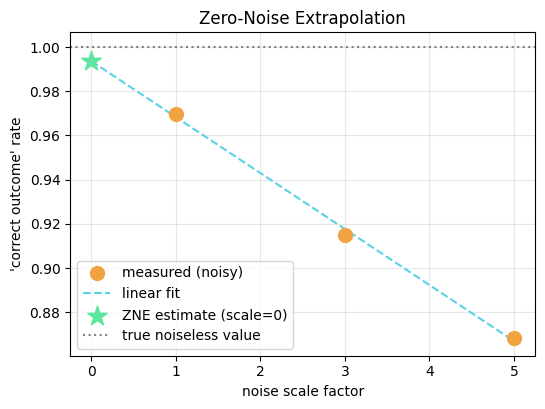

Raw measurement at 1x noise:        0.9698
ZNE-extrapolated estimate at 0x:    0.9936
True noiseless value:                1.0000

Error before ZNE: 0.0302
Error after ZNE:  0.0064


In [7]:
# Fit a straight line through the measured points and extrapolate back to scale = 0
coeffs = np.polyfit(scale_factors, measured_values, deg=1)
zne_estimate = np.polyval(coeffs, 0)

fit_x = np.linspace(0, 5, 50)
fit_y = np.polyval(coeffs, fit_x)

plt.figure(figsize=(6, 4.2))
plt.plot(scale_factors, measured_values, "o", markersize=10, color="#f2a341", label="measured (noisy)", zorder=3)
plt.plot(fit_x, fit_y, "--", color="#5ad1e6", label="linear fit")
plt.scatter([0], [zne_estimate], marker="*", s=220, color="#5ee6a0", label="ZNE estimate (scale=0)", zorder=4)
plt.axhline(1.0, color="gray", linestyle=":", label="true noiseless value")
plt.xlabel("noise scale factor")
plt.ylabel("'correct outcome' rate")
plt.title("Zero-Noise Extrapolation")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Raw measurement at 1x noise:        {measured_values[0]:.4f}")
print(f"ZNE-extrapolated estimate at 0x:    {zne_estimate:.4f}")
print(f"True noiseless value:                1.0000")
print(f"\nError before ZNE: {abs(measured_values[0]-1.0):.4f}")
print(f"Error after ZNE:  {abs(zne_estimate-1.0):.4f}")

The extrapolated estimate lands noticeably closer to the true noiseless value than the raw single measurement did — without ever needing an actual noiseless device. This is exactly the kind of technique used routinely on real IBM Quantum hardware today.

**Limitations worth knowing:** ZNE assumes the noise scales *predictably* as you fold gates (often true, not always), needs extra circuit executions for every scale factor (more cost), and — like readout mitigation — is a mitigation, not a cure. It reduces the *impact* of noise on your final answer; it doesn't make the underlying hardware more reliable.

### 🔧 Try it yourself
Add a fourth scale factor, `7`, to `scale_factors` and refit. Does the ZNE estimate improve, stay about the same, or get worse? *(Real hardware ZNE studies often find that too many high scale factors can actually hurt the linear fit, if the true noise isn't perfectly linear — worth confirming for yourself here.)*

In [8]:
# YOUR CODE HERE -- extend scale_factors, remeasure, refit, and compare zne_estimate


## 5. Recap & What's Next

| Technique | Fixes | Doesn't fix | Cost |
|---|---|---|---|
| **Readout mitigation** | Final measurement misclassification | Errors during gate execution | One calibration run, then near-free |
| **Zero-Noise Extrapolation** | Approximates the noiseless answer for gate errors too | Requires extra circuit runs; assumes predictable noise scaling | Several extra circuit executions per data point |

Both techniques are examples of **error mitigation** — statistically compensating for noise in post-processing — which is distinct from **error correction** (encoding logical qubits redundantly across many physical qubits so errors can be detected and fixed *during* computation). Full error correction is largely still a future-hardware capability; mitigation is what today's NISQ-era QML actually runs on.

**Next notebook: `07_real_world_case_studies.ipynb`** — Module 10. You'll apply everything from Notebooks 01–06 to two realistic case studies, comparing quantum and classical approaches head-to-head on real datasets.
